# symbol2vec -- mapping string stock symbols into vector representations

In this notebook we take stock symbols and their log returns within a fixed time window and we use a SVD to find a vector representation of each stock symbol.
The intuitive reading is that stock symbols that move together are similar (same sector, market area) and so they should be mapped to more similar vectors.

The implementation uses a TruncatedSVD by scikit-learn to compute the stock symbol embedding.

In [19]:
import sys

sys.path.append("../..")

from datetime import date
from dateutil.relativedelta import relativedelta
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import polars as pl
from scipy.linalg import orthogonal_procrustes
from sklearn.decomposition import TruncatedSVD
import warnings

from etl.transformation.silver.candles_daily import CandlesDailySilver

In [20]:
EMBEDDING_SIZE = 16
TIME_WINDOW = 12
TIME_SHIFT = 6
FIRST_DATE = date(2015, 1, 1)
FINAL_DATE = date(2026, 1, 1)

SEED = 16*29
DATAPLATFORM_ROOT = "../../dataplatform"


## Implementation

In [21]:
def load_log_returns(dataplatform_root: str, start_date: date, end_date: date) -> pl.LazyFrame:
    """Scan CandlesDailySilver from disk, restricted to [start_date, end_date)
    and to the symbol/timeframe/log_return_1d columns."""

    model = CandlesDailySilver(yfinance_data_path="", dataplatform_root=dataplatform_root)
    return (
        model.read_from_disk()
        .filter(pl.col("timeframe") >= start_date, pl.col("timeframe") < end_date)
        .select("symbol", "timeframe", "log_return_1d")
    )


def drop_incomplete_symbols(lf: pl.LazyFrame, max_missing_ratio: float = 0.1) -> pl.LazyFrame:
    """Drop symbols whose log_return_1d is missing (absent, null, or non-finite)
    on more than `max_missing_ratio` of the days in range. Symbols within the
    threshold are kept in full, with their missing days imputed from that
    day's cross-sectional mean return across the rest of the market, so the
    later pivot still has no gaps."""

    # candles_daily has occasional duplicate (symbol, timeframe) rows; collapse
    # them first so the grid below has at most one value per cell
    lf = lf.unique(subset=["symbol", "timeframe"], keep="first")

    days = lf.select("timeframe").unique()
    n_days = days.collect().height

    is_valid = pl.col("log_return_1d").is_not_null() & pl.col("log_return_1d").is_finite()

    kept_symbols = (
        lf.group_by("symbol")
        .agg(is_valid.sum().alias("n_valid"))
        .with_columns((1 - pl.col("n_valid") / n_days).alias("missing_ratio"))
        .filter(pl.col("missing_ratio") <= max_missing_ratio)
        .select("symbol")
    )

    market_mean_by_day = (
        lf.filter(is_valid)
        .group_by("timeframe")
        .agg(pl.col("log_return_1d").mean().alias("market_mean"))
    )

    # cross join gives a dense symbol x day grid, so entirely-absent rows
    # (not just null ones) also get a slot to impute into. Restrict to days that
    # have a market mean at all -- a day with zero valid entries market-wide
    # (e.g. the very first day of the whole history, where log_return_1d is
    # undefined for everyone) can't be imputed and is dropped instead.
    full_grid = kept_symbols.join(
        market_mean_by_day.select("timeframe"), how="cross"
    )
    
    return (
        full_grid.join(lf, on=["symbol", "timeframe"], how="left")
        .join(market_mean_by_day, on="timeframe", how="left")
        .with_columns(
            pl.when(is_valid)
            .then(pl.col("log_return_1d"))
            .otherwise(pl.col("market_mean"))
            .alias("log_return_1d")
        )
        .select("symbol", "timeframe", "log_return_1d")
    )


def iterate_svd_by_rolling() -> dict[date, dict[str, np.ndarray]]:
    symbol_embeddings = {}

    start_date = FIRST_DATE
    end_date = start_date + relativedelta(months=TIME_WINDOW)

    while end_date <= FINAL_DATE:
        lf = load_log_returns(DATAPLATFORM_ROOT, start_date, end_date)
        df = drop_incomplete_symbols(lf).collect()
        panel = df.pivot(on="timeframe", index="symbol", values="log_return_1d").sort("symbol")
        # pivot doesn't guarantee chronological column order, so realign explicitly
        day_columns = sorted(c for c in panel.columns if c != "symbol")
        panel = panel.select(["symbol", *day_columns])

        symbols = panel["symbol"].to_list()
        R = panel.select(day_columns).to_numpy()
        # standardize EACH SYMBOL's series (across time) so co-movement, not raw
        # volatility, drives the factors -- correlation- rather than covariance-based.
        R = (R - R.mean(axis=1, keepdims=True)) / (R.std(axis=1, keepdims=True) + 1e-8)

        embeddings = TruncatedSVD(n_components=EMBEDDING_SIZE, random_state=SEED).fit_transform(R)
        symbol_to_vec = dict(zip(symbols, embeddings))
        symbol_embeddings[end_date] = symbol_to_vec

        start_date = start_date + relativedelta(months=TIME_SHIFT)
        end_date = start_date + relativedelta(months=TIME_WINDOW)

    return symbol_embeddings


def rotate_embedding_to_latest(
    symbol_embeddings: dict[date, dict[str, np.ndarray]],
    min_shared: int | None = None,
) -> dict[date, dict[str, np.ndarray]]:
    """Align every period's embedding onto the latest period's basis via orthogonal
    Procrustes, so a symbol's vector is comparable across dates.

    SVD bases are defined only up to rotation/reflection, so raw per-period
    embeddings sit in incompatible coordinate frames. We anchor on the most recent
    period and walk backwards, aligning each period to its already-aligned successor
    (adjacent rolling windows share the most symbols -> well-conditioned rotation,
    which then composes back to the canonical frame)."""
    if not symbol_embeddings:
        return {}

    dates = sorted(symbol_embeddings)                       # ascending; last is canonical
    dim = len(next(iter(symbol_embeddings[dates[-1]].values())))
    if min_shared is None:
        min_shared = dim                                    # >= dim to pin a rotation; more is better

    def as_arrays(d: date) -> dict[str, np.ndarray]:
        return {s: np.asarray(v, dtype=float) for s, v in symbol_embeddings[d].items()}

    aligned: dict[date, dict[str, np.ndarray]] = {dates[-1]: as_arrays(dates[-1])}

    for i in range(len(dates) - 2, -1, -1):
        cur = as_arrays(dates[i])
        ref = aligned[dates[i + 1]]                         # already in canonical frame
        # for direct-to-canonical instead of chaining, use: ref = aligned[dates[-1]]

        shared = sorted(cur.keys() & ref.keys())
        if len(shared) < min_shared:
            warnings.warn(
                f"{dates[i]}: only {len(shared)} shared symbols (<{min_shared}); left unrotated"
            )
            aligned[dates[i]] = cur
            continue

        A = np.vstack([cur[s] for s in shared])             # this period, raw
        B = np.vstack([ref[s] for s in shared])             # successor, already aligned
        R, _ = orthogonal_procrustes(A, B)                  # minimizes ||A @ R - B||, R orthogonal

        aligned[dates[i]] = {s: v @ R for s, v in cur.items()}  # apply to ALL symbols in period

    return aligned


def store_embeddings(
    symbol_embeddings: dict[date, dict[str, np.ndarray]],
    hive_partitioned: bool,
) -> None:
    """Persist aligned embeddings as a point-in-time parquet table.

    Schema: not_before (Date), symbol (Utf8), e0..e{k-1} (Float64). `not_before`
    is the window end date the vector was computed from, so a downstream as-of join
    can pick, for a sample dated t, the latest row with not_before <= t and never a
    future embedding."""

    frames = []
    for not_before, sym_to_vec in symbol_embeddings.items():
        symbols = list(sym_to_vec.keys())
        mat = np.vstack([np.asarray(sym_to_vec[s], dtype=float) for s in symbols])  # (n, k)

        data: dict[str, object] = {
            "not_before": [not_before] * len(symbols),
            "symbol": symbols,
        }
        for j in range(mat.shape[1]):
            data[f"e{j}"] = mat[:, j]
        frames.append(pl.DataFrame(data))

    out = pl.concat(frames, how="vertical").sort("not_before", "symbol")
    if hive_partitioned:
        out.write_parquet(Path(DATAPLATFORM_ROOT) / "special" / "symbol_embeddings", partition_by="not_before")
    else:
        out.write_parquet(Path(DATAPLATFORM_ROOT) / "special" / "symbol_embeddings.parquet")

    # if all_symbols is not None and missing_out is not None:
    #     embedded = set().union(*(d.keys() for d in symbol_embeddings.values()))
    #     missing = sorted(set(all_symbols) - embedded)
    #     pl.DataFrame({"symbol": missing}).write_csv(missing_out)



The following cell builds the parquet table for embeddings by using the functions above. To better understand what is going on see the walkthrough section which copies some code from the functions above and shows the process step by step

In [22]:
symbol_embeddings = iterate_svd_by_rolling()
symbol_embeddings = rotate_embedding_to_latest(symbol_embeddings)
store_embeddings(symbol_embeddings, hive_partitioned=True)

[19:28:24] Loading from disk data model candles_daily
[19:28:24] silver/candles_daily scan plan ready from disk
[19:28:25] Loading from disk data model candles_daily
[19:28:25] silver/candles_daily scan plan ready from disk
[19:28:27] Loading from disk data model candles_daily
[19:28:27] silver/candles_daily scan plan ready from disk
[19:28:28] Loading from disk data model candles_daily
[19:28:28] silver/candles_daily scan plan ready from disk
[19:28:29] Loading from disk data model candles_daily
[19:28:29] silver/candles_daily scan plan ready from disk
[19:28:31] Loading from disk data model candles_daily
[19:28:31] silver/candles_daily scan plan ready from disk
[19:28:32] Loading from disk data model candles_daily
[19:28:32] silver/candles_daily scan plan ready from disk
[19:28:33] Loading from disk data model candles_daily
[19:28:33] silver/candles_daily scan plan ready from disk
[19:28:35] Loading from disk data model candles_daily
[19:28:35] silver/candles_daily scan plan ready fr

## Walkthrough

Read from the `silver.candles_daily` table and select only the columns `timeframe`, `symbol`, `log_return_1d`. We use returns instead of raw price, because prices have wide shifts in magnitude across symbols, while returns are more consistent; log-returns specifically for their symmetry around 0 and especially because they are additive (ie linear) over time ($lr_{t_1,t_2})=\sum_{t=t_1}^{t_2} lr_t$) which is a requirement for the SVD

In [35]:
lf = load_log_returns(DATAPLATFORM_ROOT, date(2021, 1, 1), date(2022, 1, 1))
df = drop_incomplete_symbols(lf).collect()
print(f"dataframe shape: {df.shape}")
df.head()

[19:33:01] Loading from disk data model candles_daily
[19:33:01] silver/candles_daily scan plan ready from disk
dataframe shape: (1631448, 3)


symbol,timeframe,log_return_1d
str,date,f64
"""KIM-PM""",2021-09-09,-0.001524
"""KIM-PM""",2021-01-11,-0.009673
"""KIM-PM""",2021-01-05,0.004265
"""KIM-PM""",2021-05-19,-0.010987
"""KIM-PM""",2021-04-28,-0.000938


Then we need to pivot the data: the matrix R constructed here is a matrix with one row per stock symbol $s$ and one column per selected date $d$. The value at $R_{s,d}$ is the 1 day log return registered for stock symbol $s$ at day $d$.
Values are standardized first (zero mean and unit variance) on a per-symbol basis, meaning that the mean and variance used to standardize values of symbol $s$ are only computed from $s$' row

In [36]:
panel = df.pivot(on="timeframe", index="symbol", values="log_return_1d").sort("symbol")

# pivot doesn't guarantee chronological column order, so realign explicitly
day_columns = sorted(c for c in panel.columns if c != "symbol")
panel = panel.select(["symbol", *day_columns])

symbols = panel["symbol"].to_list()
R = panel.select(day_columns).to_numpy()
# standardize EACH SYMBOL's series (across time) so co-movement, not raw
# volatility, drives the factors -- correlation- rather than covariance-based.
# No NaNs survive drop_incomplete_symbols, so plain mean/std is enough.
R = (R - R.mean(axis=1, keepdims=True)) / (R.std(axis=1, keepdims=True) + 1e-8)
print(f"pivoted returns matrix shape: {R.shape}")

pivoted returns matrix shape: (6474, 252)


Compute symbol embeddings by SVD: let $R=U\Sigma V^T$ be the SVD of $R$, take the first `EMBEDDING_SIZE` columns of $U$ and the first `EMBEDDING_SIZE` columns/rows of $\Sigma$ and multiply them together. The result is a matrix with one row per symbol and exactly `EMBEDDING_SIZE` columns and each of these rows is the symbol embedding.

Why U is the symbol representation: symbol `i`'s entire return series is `R[i,:] = U[i,:] · Σ · Vᵀ`. That says symbol `i`'s series is a blend of the `k` factor time-patterns (rows of `Vᵀ`), mixed with weights `U[i,:]·Σ`. Those mixing weights — "how much of each co-movement factor is in this stock" — are the desired embedding

In [37]:
embeddings = TruncatedSVD(n_components=EMBEDDING_SIZE, random_state=SEED).fit_transform(R)
symbol_to_vec = dict(zip(symbols, embeddings))
embeddings.shape

(6474, 16)

Mapping table is stored under the `special` layer in the dataplatform.
Note that parquet doesn't have a first-class fixed-size vector column, so the embedding is stored as one float column per dimension (`dim_0`, `dim_1`, ...).

In [38]:
embedding_columns = {f"dim_{i}": embeddings[:, i] for i in range(EMBEDDING_SIZE)}
lookup = pl.DataFrame({"symbol": symbols, **embedding_columns})

special_dir = Path(DATAPLATFORM_ROOT) / "special"
special_dir.mkdir(parents=True, exist_ok=True)
lookup.write_parquet(special_dir / "symbol_embedding.parquet")
lookup.head()

symbol,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,dim_9,dim_10,dim_11,dim_12,dim_13,dim_14,dim_15
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""A""",-7.363868,5.443945,-4.609713,4.606599,-5.069266,0.147773,0.212899,-0.11634,0.733076,-0.432472,0.9913,-0.048082,-0.536827,-1.055921,-1.546557,-0.046653
"""AA""",-9.314764,-2.758562,3.627789,-3.444635,-0.487716,1.00083,2.504731,1.038473,0.268835,-0.144578,0.653504,1.357481,0.10427,-1.784586,-0.597686,0.147024
"""AAAU""",-3.116205,2.245559,-1.850638,-8.374003,-3.952507,-6.076286,-2.500293,2.686457,-5.956419,-2.074409,0.734289,0.284425,-0.506174,-0.208833,-0.207188,-0.029674
"""AACG""",-2.693067,0.755052,0.892406,2.089078,1.213658,1.586569,-1.223308,0.351646,2.46496,0.071607,-0.369324,-0.021276,1.005854,-0.085153,-1.390251,3.866287
"""AAGH""",1.518754,0.653301,2.890221,1.481113,3.438172,-7.486961,4.35866,2.221461,1.790641,1.272985,-1.758731,0.282545,0.639385,2.041234,0.812235,-2.042556


If the embedding is doing its job, pairs of companies from the same sector (and therefore prone to moving together) should sit closer together in vector space than pairs from unrelated sectors.

AAPL  vs MSFT  [big tech       ] cosine similarity = +0.954
KO    vs PEP   [soft drinks    ] cosine similarity = +0.902
XOM   vs CVX   [oil majors     ] cosine similarity = +0.990
AAPL  vs XOM   [tech vs oil    ] cosine similarity = +0.065
KO    vs NVDA  [staples vs semis] cosine similarity = +0.129


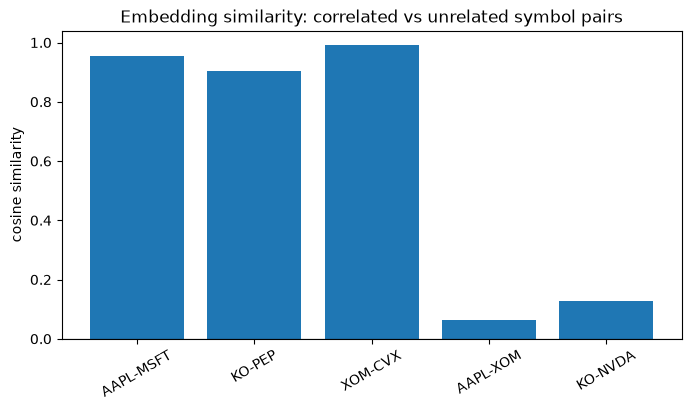

In [39]:
def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

# a few pairs with a well known sector relationship, used only as a sanity check
pairs = [
    ("AAPL", "MSFT", True, "big tech"),
    ("KO", "PEP", True, "soft drinks"),
    ("XOM", "CVX", True, "oil majors"),
    ("AAPL", "XOM", False, "tech vs oil"),
    ("KO", "NVDA", False, "staples vs semis"),
]

for a, b, expected_correlated, label in pairs:
    if a not in symbol_to_vec or b not in symbol_to_vec:
        print(f"skipping {a}/{b} ({label}): missing from embeddings")
        continue
    sim = cosine_similarity(symbol_to_vec[a], symbol_to_vec[b])
    print(f"{a:5s} vs {b:5s} [{label:15s}] cosine similarity = {sim:+.3f}")


available = [(a, b, label) for a, b, _, label in pairs if a in symbol_to_vec and b in symbol_to_vec]
sims = [cosine_similarity(symbol_to_vec[a], symbol_to_vec[b]) for a, b, _ in available]
labels = [f"{a}-{b}" for a, b, _ in available]

plt.figure(figsize=(8, 4))
plt.bar(labels, sims)
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("cosine similarity")
plt.title("Embedding similarity: correlated vs unrelated symbol pairs")
plt.xticks(rotation=30)
plt.show()

Symbols present in `CandlesDailySilver` that were dropped before reaching the SVD (out of the `[START_DATE, END_DATE)` window entirely, or missing/non-finite `log_return_1d` on at least one day of it).

In [40]:
# all_symbols = (
#     CandlesDailySilver(yfinance_data_path="", dataplatform_root=DATAPLATFORM_ROOT)
#     .read_from_disk()
#     .select("symbol")
#     .unique()
#     .collect()
#     .to_series()
#     .to_list()
# )

# missing_symbols = sorted(set(all_symbols) - set(symbols))
# pl.DataFrame({"symbol": missing_symbols}).write_csv(special_dir / "symbols_without_embedding.csv")
# len(missing_symbols)